In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Load training dataset

df = pd.read_csv("train.csv", index_col = "Id")

In [5]:
# Data overview

print("df shape: ", df.shape)
print("Missing values: \n", df.isnull().sum().sort_values(ascending=False))
print("Data types: \n", df.dtypes.value_counts())
df.head()


df shape:  (1460, 80)
Missing values: 
 PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 80, dtype: int64
Data types: 
 str        43
int64      34
float64     3
Name: count, dtype: int64


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


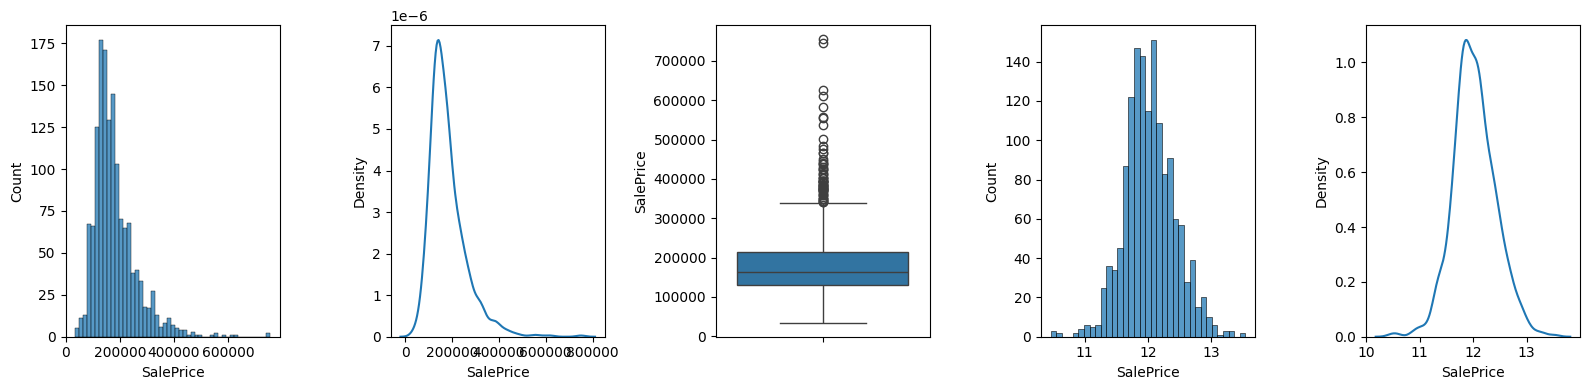

In [6]:
# Target variable exploration

fig, axes = plt.subplots(ncols=5, figsize = (16, 4)) 

sns.histplot(df["SalePrice"], ax=axes[0])
sns.kdeplot(df["SalePrice"], ax=axes[1])
sns.boxplot(df["SalePrice"], ax=axes[2])
sns.histplot(np.log1p(df["SalePrice"]), ax=axes[3])
sns.kdeplot(np.log1p(df["SalePrice"]), ax=axes[4])

plt.tight_layout()
plt.show()

Since house prices appear normally distributed under log transform, the new target variable will be log(SalePrice), to be convert back to SalePrice after prediction.

In [ ]:
# Missing value analysis

missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64

In [26]:
# Fill missing with None

cols_to_fill_with_NA = ["PoolQC", "MiscFeature", "Alley", "Fence", "MasVnrType", "FireplaceQu", "GarageType", "GarageQual", "GarageCond", "BsmtExposure", "BsmtFinType2", "BsmtQual", "BsmtCond", "BsmtFinType1", "Electrical"]

df[cols_to_fill_with_NA] = df[cols_to_fill_with_NA].fillna("None")

In [35]:
# Fill missing lot frontage with 0

df["LotFrontage"] = df["LotFrontage"].fillna(0)

In [33]:
# Fill MasVnrArea by median of MasVnrType

df['MasVnrArea'] = df['MasVnrArea'].fillna(
    df.groupby('MasVnrType')['MasVnrArea'].transform('median')
)

In [36]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

GarageYrBlt     81
GarageFinish    81
dtype: int64